<div class="alert alert-block alert-success">
    <h1 align="center">Text-Based Emotion Recognition | Using Glove</h1>
    <h3 align="center">Text Classification</h3>
    
<a href="https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp">
About Dataset
    </a>
<br />
<a href="https://apptextbaseemotionclassification-rwwrzbw7ushct9avqpwyrx.streamlit.app/">
Text Emotion Recognition — Streamlit App
    </a>
</div>

<img src="https://static.vecteezy.com/system/resources/previews/007/504/538/large_2x/emotion-levels-on-the-scale-of-different-faces-icon-design-element-for-feedback-review-rating-product-review-a-set-of-emoji-with-different-emotions-on-a-white-background-illustration-vector.jpg" 
     style="width: 100%; max-width: 1200px; object-fit: cover; display: block; margin: 0 auto; border-radius: 8px;">

<div style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6; ">
    <h2 style="text-align: center; color: #007400; margin-top: 0;">
        Welcome to my Notebook...!
    </h2>
    <p style="text-align: justify; margin-bottom: 20px;">
In this notebook, we will build a text classification model using 100-dimensional pre-trained GloVe embeddings and a 1D Convolutional Neural Network (Conv1D) to classify sentences based on their underlying emotions.
    </p>
<p style="text-align: justify; margin-bottom: 20px;">
The dataset contains sentences labeled with emotions such as joy, sadness, anger, fear, love, and surprise.
Our goal is to build a deep learning model that can automatically detect the underlying emotion in a given sentence.
</p>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Import required libraries
    </p>
</div>

In [1]:
import os
from pathlib import Path
from collections import defaultdict
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
#---
from wordcloud import WordCloud
#---
import tensorflow as tf
from tensorflow import keras
#---
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_curve,auc, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
#---
import warnings
warnings.filterwarnings('ignore')

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.1 Paths & Quick Inspect
    </p>
</div>

In [2]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
max_tokens = 10000
max_sequence = 100
#---
root_dir = Path("Emotion for NLP")
train_dir = root_dir / 'train.txt'
val_dir = root_dir / 'val.txt'
test_dir = root_dir / 'test.txt'
#---
class COLOR:
    blue = '\033[94m'
    green = '\033[32m'
    yellow = '\033[33m'
    red = '\033[31m'
    brown = '\033[33m'
    end = '\033[0m'

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.2 Extracting Text Paths and Labels from Directory
    </p>
</div>

In [3]:
raw_train_text =[]
raw_val_text = []
raw_test_text = []
#--
train_label =[]
val_label = []
test_label =[]
#Train
with open (train_dir, mode='r', encoding='utf-8') as file:
    for line in file:
        line = line.strip()
        text, label = line.split(';')
        raw_train_text.append(text)
        train_label.append(label)
        
#Validation:
with open (val_dir, mode='r', encoding='utf-8') as file:
    for line in file:
        line = line.strip()
        text, label = line.split(';')
        raw_val_text.append(text)
        val_label.append(label)
        
#Test:
with open (test_dir, mode='r', encoding='utf-8') as file:
    for line in file:
        line = line.strip()
        text, label = line.split(';')
        raw_test_text.append(text)
        test_label.append(label)
#---
print('Train Samples: ', len(raw_train_text))
print('Train Labels : ', len(train_label))
#---
print('\nVal Samples: ', len(raw_val_text))
print('Val Labels : ', len(val_label))
#---
print('\nTest Samples: ', len(raw_test_text))
print('Test Labels : ', len(test_label))
#---

Train Samples:  16000
Train Labels :  16000

Val Samples:  2000
Val Labels :  2000

Test Samples:  2000
Test Labels :  2000


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        2. Data Overview
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Unique Labels and Sample Examples
         </li>
        </ul>
</div>

In [4]:
print(f'{COLOR.red}Unique Labels:\n{COLOR.end} {np.unique(train_label)} \n {'-'*50}')
#---
print(f'{COLOR.red}Samples:{COLOR.end}')
for i in range(50,53,1):
    print(f'{COLOR.blue}Text{i}:{COLOR.end} {raw_train_text[i]} - {COLOR.blue}Label: {train_label[i]}{COLOR.end}')


Unique Labels:
 ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise'] 
 --------------------------------------------------
Samples:
Text50: i need to feel the dough to make sure its just perfect - Label: joy
Text51: i found myself feeling a little discouraged that morning - Label: sadness
Text52: i feel selfish and spoiled - Label: anger


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Emotion Label Distribution Across Train, Validation & Test Sets
         </li>
        </ul>
</div>

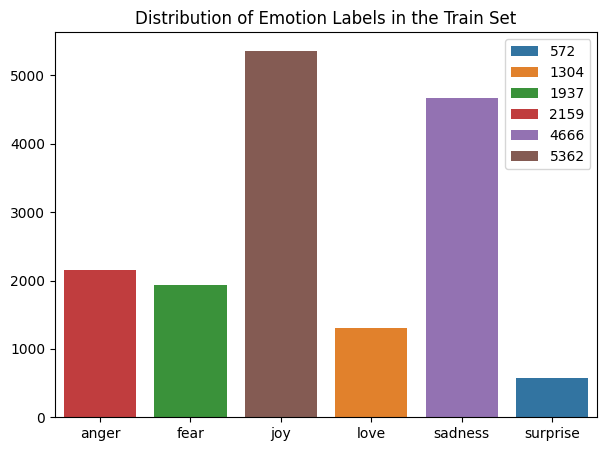

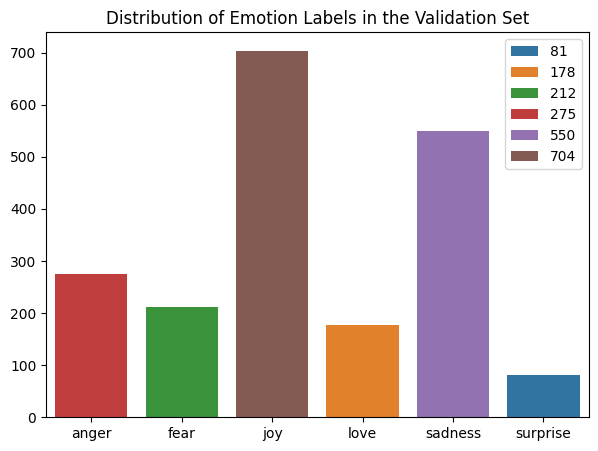

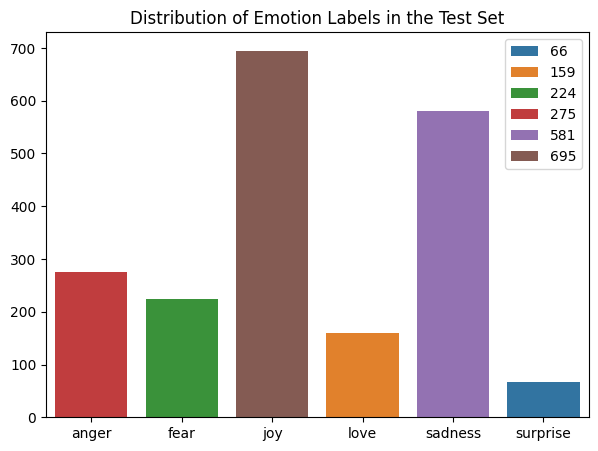

In [5]:
list_labels = [train_label, val_label, test_label]
list_names = ['Train', 'Validation', 'Test']

for name, label in zip(list_names, list_labels):
    plt.figure(figsize=(7, 5))
    sns.barplot(x=np.unique_counts(label).values,
                y=np.unique_counts(label).counts,
                hue=np.unique_counts(label).counts, 
                palette='tab10')
    plt.title(f'Distribution of Emotion Labels in the {name} Set')
    plt.legend()
    plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Character and Word Distributions
         </li>
        </ul>
</div>

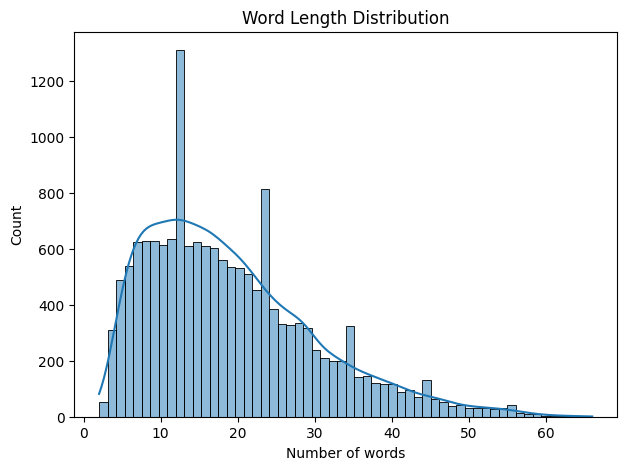

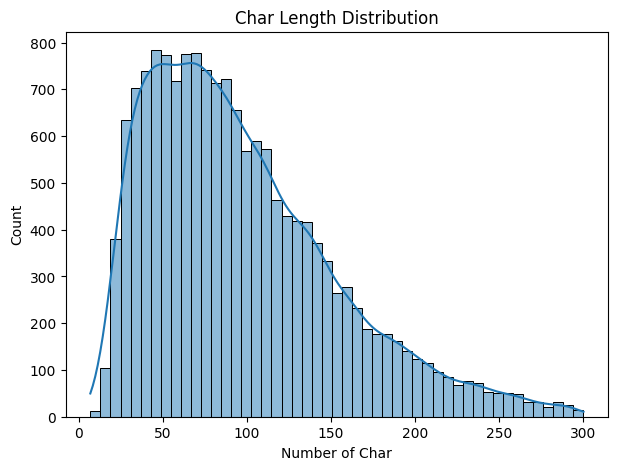

In [6]:
char_length = []
word_length = []
for i in range(len(raw_train_text)):
    char_length.append(len(raw_train_text[i]))
    word_length.append(len(raw_train_text[i].split()))
    
#number of word plot:
plt.figure(figsize=(7,5))
sns.histplot(word_length, kde=True)
plt.title("Word Length Distribution")
plt.xlabel("Number of words")
plt.show()

#number of char plot:
plt.figure(figsize=(7,5))
sns.histplot(char_length, kde=True)
plt.title("Char Length Distribution")
plt.xlabel("Number of Char")
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Word Clouds per Emotion
         </li>
        </ul>
</div>

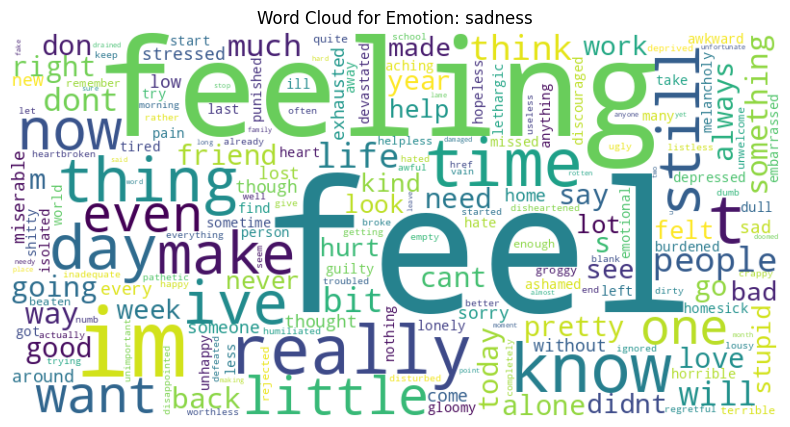

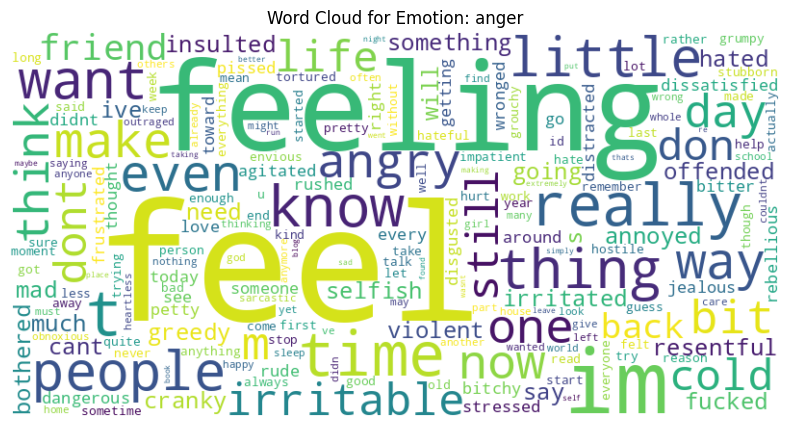

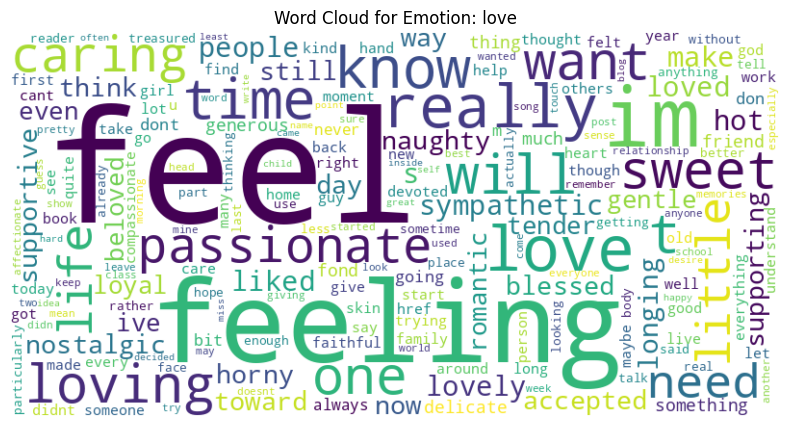

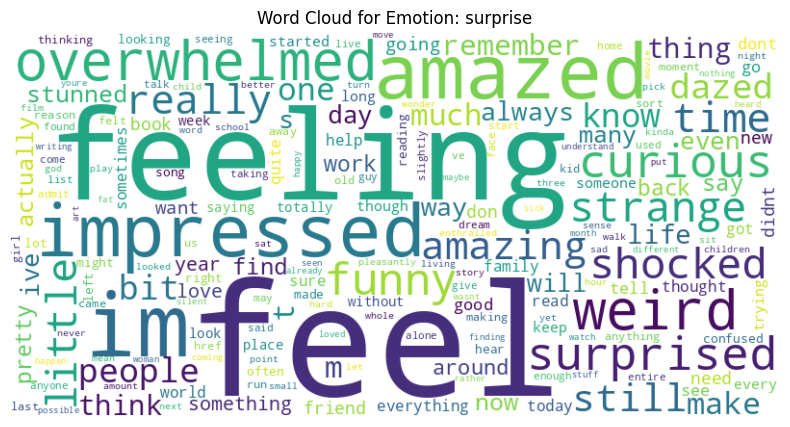

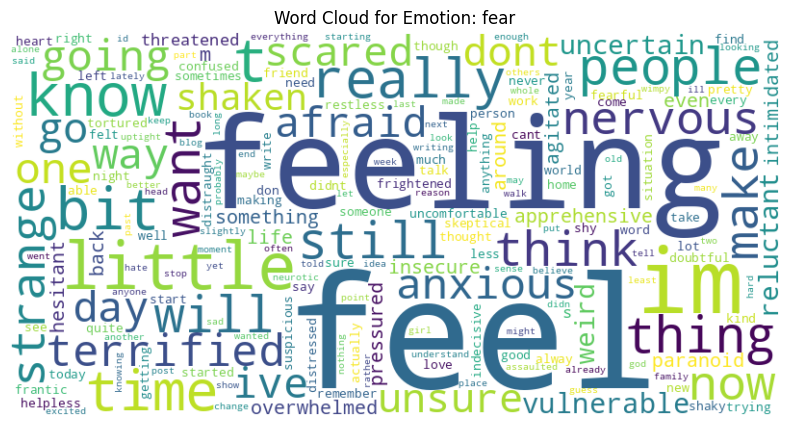

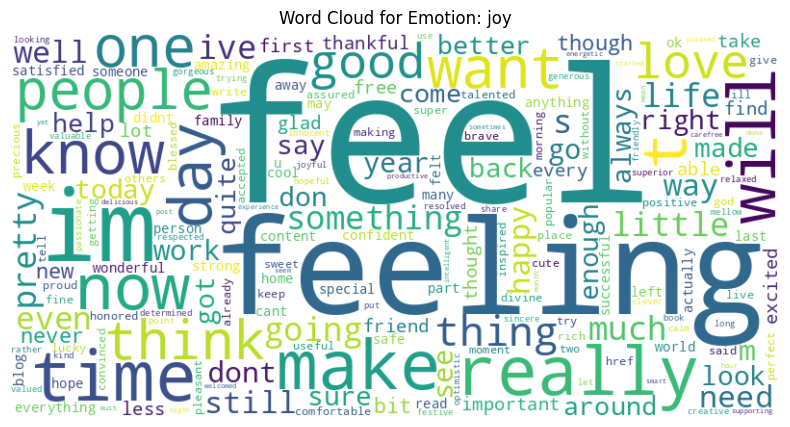

In [7]:
emotion_texts = defaultdict(list)

for text, label in zip(raw_train_text, train_label):
    emotion_texts[label].append(text)

for emotion, text_list in emotion_texts.items():
    
    combined_text = " ".join(text_list)
    
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        collocations=False        
    ).generate(combined_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Emotion: {emotion}')
    plt.show()

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        3. Data Preparation
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Convert Emotions to Integers
         </li>
        </ul>
</div>

In [8]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(train_label)
y_val = encoder.transform(val_label)
y_test = encoder.transform(test_label)
#---
label_map = {}
for i in range(len(np.unique(train_label))):
    label_map[i]=str(encoder.classes_[i])
print(f'{COLOR.red}Label Map: {COLOR.end}{COLOR.blue}{label_map}')

Label Map: {0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Create Datasets:
         </li>
        </ul>
</div>

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices((raw_train_text, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((raw_val_text, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((raw_test_text, y_test))

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Create Vocabulary and Adapt
         </li>
        </ul>
</div>

In [10]:
vectorize_layer = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=max_sequence)

#Adapt
vectorize_layer.adapt(raw_train_text)
#---
#vocabulary

print(f'{COLOR.red}Vocabulary Length: {COLOR.end}{len(vectorize_layer.get_vocabulary())}')
print(f'{COLOR.red}5 first token:{COLOR.end} {vectorize_layer.get_vocabulary()[:5]}')
#--
output = vectorize_layer([['We love cats']])
print(f'{COLOR.red}Token Indexing:{COLOR.end}{output.numpy()[0,:3]}')

Vocabulary Length: 10000
5 first token: ['', '[UNK]', np.str_('i'), np.str_('feel'), np.str_('and')]
Token Indexing:[  82   85 7128]


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Load GloVe Word Vectors
         </li>
        </ul>
</div>

In [11]:
# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip -q glove.6B.zip

path_to_glove_file = r'glove.6B.100d.txt'

embeddings_index= {}
with open(path_to_glove_file, encoding='utf-8') as file:
    for line in file:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs,'f',sep=' ')
        embeddings_index[word] = coefs
print(f'Found {len(embeddings_index)} word vectors')

Found 400000 word vectors


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
        Build Embedding Matrix using Pre-trained GloVe
         </li>
        </ul>
</div>

In [12]:
voc = vectorize_layer.get_vocabulary()
word_index = dict(zip(voc, range(len(voc))))
num_tokens = len(voc) 
embedding_dim = 100
hits = 0
misses = 0

embedding_matrix = np.zeros((num_tokens, embedding_dim))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print(f'Converted {hits} words (misses {misses})')

Converted 9627 words (misses 373)


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Create Embedding Layer with Pre-trained GloVe Weights
         </li>
        </ul>
</div>

In [13]:
embedding_layer = keras.layers.Embedding(
    input_dim = max_tokens,
    output_dim = embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=True)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Prepare Text Data for Embedding and Build Final Datasets for Training
         </li>
        </ul>
</div>



In [14]:
def vectorize_text(text, label):
    return vectorize_layer(text), label
#---
train = train_ds.map(vectorize_text).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)
val = val_ds.map(vectorize_text).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)
test = test_ds.map(vectorize_text).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        4. Build And Training Model
    </p>
</div>

In [15]:
int_sequences_input = keras.Input(shape=(None,), dtype="int64")
embedded_sequences = embedding_layer(int_sequences_input)
x = keras.layers.Conv1D(128, 3, activation="relu")(embedded_sequences)
x = keras.layers.MaxPooling1D(3)(x)
x = keras.layers.Conv1D(128, 3, activation="relu")(x)
x = keras.layers.MaxPooling1D(3)(x)
x = keras.layers.Conv1D(128, 3, activation="relu")(x)
x = keras.layers.GlobalMaxPooling1D()(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.5)(x)
preds = keras.layers.Dense(len(label_map), activation="softmax")(x)
model = keras.Model(int_sequences_input, preds)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, None, 100)           │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, None, 128)           │          38,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, None, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, None, 128)           │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, None, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, None, 128)           │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,154,374 (4.40 MB)

 Trainable params: 1,154,374 (4.40 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(train, epochs=3, validation_data=(val))

Epoch 1/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.5711 - loss: 1.1147 - val_accuracy: 0.8360 - val_loss: 0.4552
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.8907 - loss: 0.3203 - val_accuracy: 0.9170 - val_loss: 0.2517
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9411 - loss: 0.1689 - val_accuracy: 0.9225 - val_loss: 0.2345


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        5. Model Evaluation
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Performance Analysis
         </li>
        </ul>
</div>

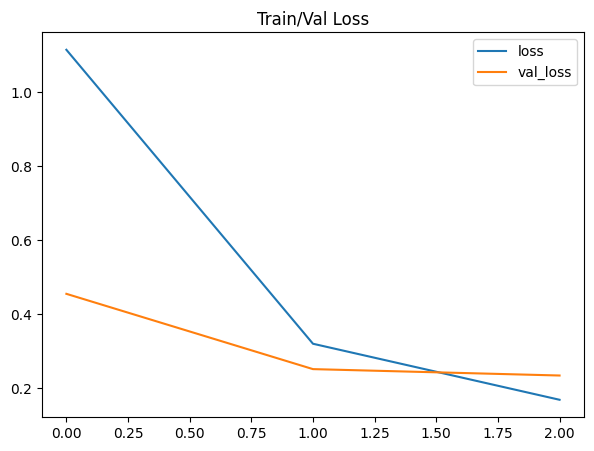

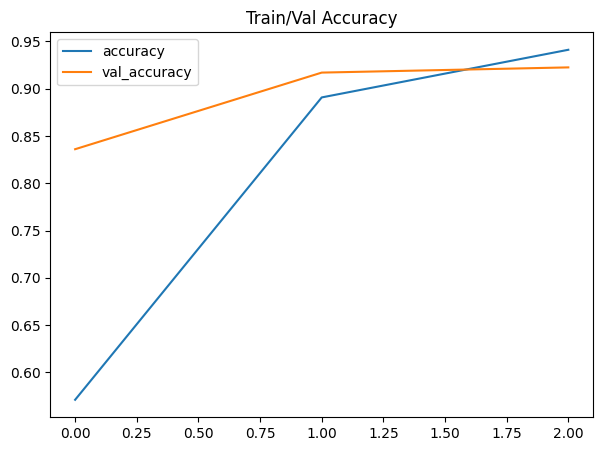

In [17]:
#print(history.history.keys())
#Loss
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Train/Val Loss')
plt.legend()
plt.show()
#ACC
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Train/Val Accuracy')
plt.legend()
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Classification Report and Confusion Matrix (Test Set)
         </li>
        </ul>
</div>

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       275
           1       0.91      0.89      0.90       224
           2       0.93      0.94      0.94       695
           3       0.78      0.79      0.79       159
           4       0.97      0.96      0.96       581
           5       0.83      0.65      0.73        66

    accuracy                           0.92      2000
   macro avg       0.89      0.86      0.87      2000
weighted avg       0.92      0.92      0.92      2000



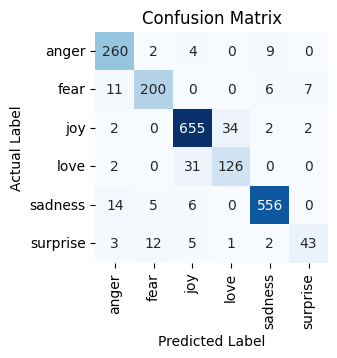

In [18]:
y_pred = model.predict(test)
pred = y_pred.argmax(axis=1)
#---
print(classification_report(y_test, pred))
#---

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(3,3))
sns.heatmap(cm, cbar=False, annot=True,
            cmap='Blues', annot_kws={'size':10},
            fmt='.0f', xticklabels=label_map.values(), 
            yticklabels=label_map.values())
plt.title('Confusion Matrix')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Multi-Class ROC Curve Evaluation
         </li>
        </ul>
</div>

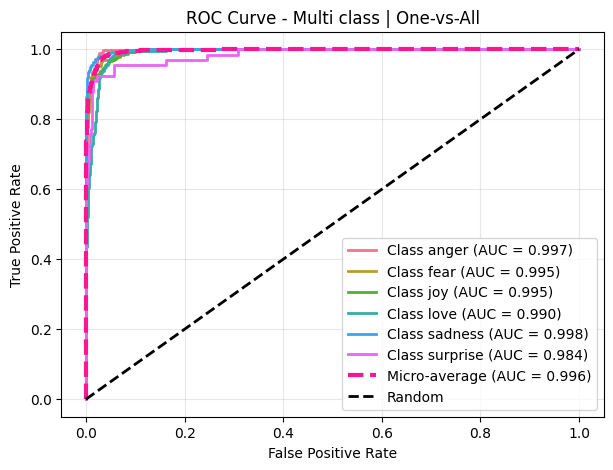

In [19]:
n_classes=6
colors = sns.color_palette("husl", n_classes)
label_oh = keras.utils.to_categorical(y_test)
plt.figure(figsize=(7, 5))
#---
#Roc Curve Plot:
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(label_oh[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'Class {list(label_map.values())[i]} (AUC = {roc_auc:.3f})')
#---
# ROC Micro AVG PLot:
fpr_micro, tpr_micro, _ = roc_curve(label_oh.ravel(), y_pred.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle='--', linewidth=3,
         label=f'Micro-average (AUC = {roc_auc_micro:.3f})')
#---
# Random Line Plot: 
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multi class | One-vs-All')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        6. Export Model And Prediction Example
    </p>
</div>

In [20]:
#Export Model:
string_input = keras.Input(shape=(1,), dtype="string")
x = vectorize_layer(string_input)
pred = model(x)
end_to_end_model = keras.Model(string_input, pred)
#---

sample_texts = tf.constant([
    "I am so happy today!",
    "I feel very sad and lonely",
    "This makes me really angry!",
    "I am surprised by the news"
])
prediction = end_to_end_model.predict(sample_texts)
prediction = prediction.argmax(axis=1)

for text, pred in zip(sample_texts, prediction):
    print(f'{COLOR.blue}{text}{COLOR.end} {COLOR.red}-> {label_map[pred]}{COLOR.end}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
b'I am so happy today!' -> joy
b'I feel very sad and lonely' -> sadness
b'This makes me really angry!' -> anger
b'I am surprised by the news' -> surprise


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        Thanks a lot for going through this notebook! I hope it was helpful and worth your time.
    </p>
</div>